# Prompt 9 - Video Processing Layer

This notebook demonstrates deterministic video ingestion and frame utilities without pose estimation or feature extraction.


In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.video_processing import (
    Video,
    VideoPreprocessingConfig,
    first_frame_preview,
    frame_timeline,
    last_frame_preview,
    playback_preview,
    save_frames,
)


In [2]:
video = Video('reports/video_processing/sample_video.avi')
video.metadata


VideoMetadata(filename='sample_video.avi', path='reports/video_processing/sample_video.avi', duration=2.0, frame_count=24, fps=12.0, width=96, height=64, codec='MJPG')

In [3]:
frame0 = video.get_frame(0)
frame_at_half_second = video.get_frame_at_timestamp(0.5)
frame0.shape, frame_at_half_second.shape


((64, 96, 3), (64, 96, 3))

In [4]:
config = VideoPreprocessingConfig(resize=(48, 32), grayscale=True, normalize=True, sample_every_n=4)
sampled_frames = list(video.iter_frames(config))
len(sampled_frames), sampled_frames[0].shape, sampled_frames[0].dtype


(6, (32, 48), dtype('float32'))

In [5]:
clip_by_frames = video.select_clip_by_frames(2, 6)
clip_by_time = video.select_clip_by_timestamps(0.2, 0.5)
len(clip_by_frames), len(clip_by_time)


(5, 5)

In [6]:
paths = save_frames(video.extract_frames([0, 6, 12]), 'reports/video_processing/notebook_frames')
[str(path) for path in paths]


['reports/video_processing/notebook_frames/frame_0000.png',
 'reports/video_processing/notebook_frames/frame_0001.png',
 'reports/video_processing/notebook_frames/frame_0002.png']

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'sample_video.avi first frame'}>)

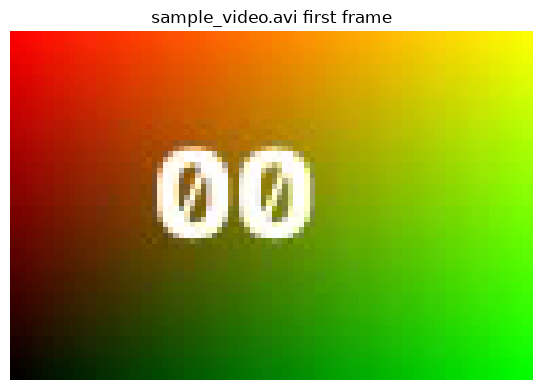

In [7]:
first_frame_preview(video)


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'sample_video.avi last frame'}>)

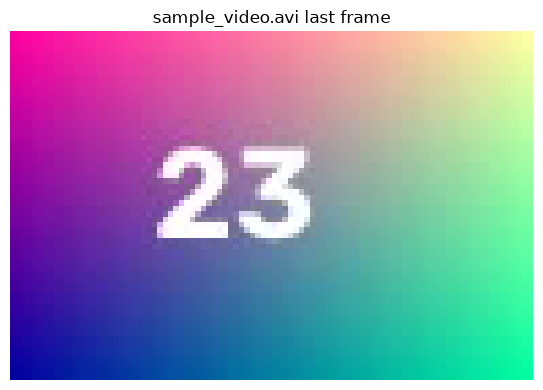

In [8]:
last_frame_preview(video)


(<Figure size 1560x240 with 6 Axes>,
 array([<Axes: title={'center': 'Frame 0'}>,
        <Axes: title={'center': 'Frame 4'}>,
        <Axes: title={'center': 'Frame 9'}>,
        <Axes: title={'center': 'Frame 13'}>,
        <Axes: title={'center': 'Frame 18'}>,
        <Axes: title={'center': 'Frame 23'}>], dtype=object))

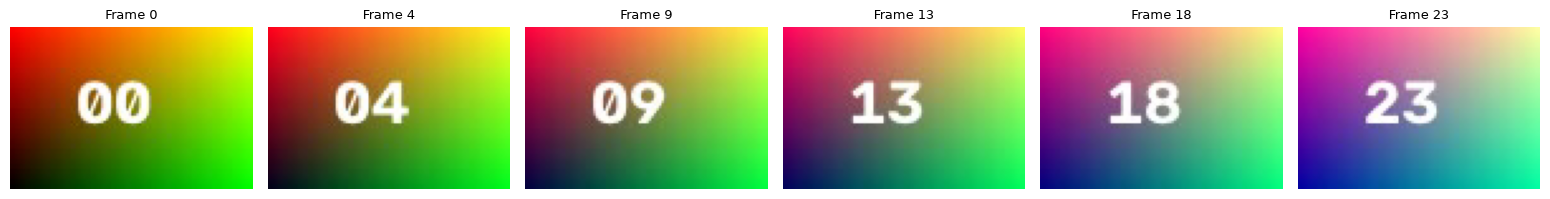

In [9]:
playback_preview(video, max_frames=6)


(<Figure size 800x260 with 1 Axes>,
 <Axes: title={'center': 'sample_video.avi frame timeline'}, xlabel='Time (s)', ylabel='Frame index'>)

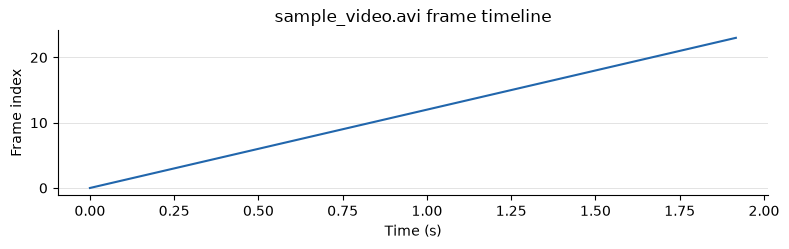

In [10]:
frame_timeline(video)
